In [ ]:
# 1. IMPORT LIBRARIES

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# 2. LOAD & CLEAN DATA

In [3]:
try:
    df = pd.read_csv('spam.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Keep only necessary columns and drop trailing empty columns if they exist
df = df.iloc[:, [0, 1]]
df.columns = ['label', 'text']

# Drop missing values and duplicates to ensure high-quality data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Map target text labels to binary numbers: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Dataset Loaded Successfully! Total unique records: {df.shape[0]}")
print(df['label'].value_counts())
print("-" * 50)

Dataset Loaded Successfully! Total unique records: 5169
label
ham     4516
spam     653
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
# 3. SPLIT DATA INTO TRAIN/TEST SETS

In [6]:
# 80% training for learning patterns, 20% testing to evaluate accuracy
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], 
    df['label_num'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label_num'] # Ensures equal spam/ham distribution in both sets
)

In [7]:
def clean_text(text):
    """
    Cleans raw text by lowering case and stripping non-alphabetic characters.
    Note: TfidfVectorizer has built-in tokenization and stop-word removal,
    but manual regex cleaning ensures uniform format.
    """
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Removes punctuation and numbers
    return text

# Apply the custom clean to training and testing text arrays
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [8]:
# 5. BUILD AND TRAIN THE MACHINE LEARNING PIPELINE

In [9]:
# TF-IDF converts words to numeric weights based on frequency and importance
# stop_words='english' automatically filters out common junk words like 'the', 'is'
model_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('classifier', MultinomialNB())
])

# Fit the entire pipeline on the clean training text data
model_pipeline.fit(X_train_clean, y_train)
print("Model pipeline trained successfully!\n")

Model pipeline trained successfully!



In [ ]:
# 6. EVALUATE THE MODEL PERFORMANCE

Overall Model Accuracy: 96.62%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



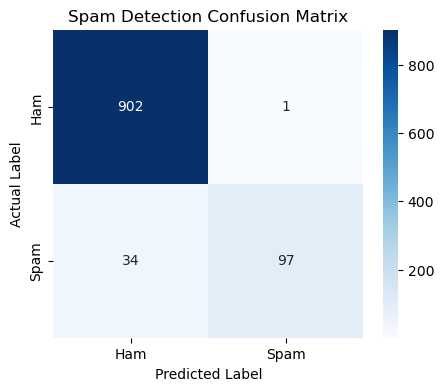

In [10]:
predictions = model_pipeline.predict(X_test_clean)

# Output evaluation metrics
accuracy = accuracy_score(y_test, predictions)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Spam Detection Confusion Matrix')
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

# ==========================================
# UPGRADED PIPELINE
# ==========================================
# 1. ngram_range=(1, 2) looks at single words AND word pairs
# 2. LogisticRegression with class_weight='balanced' forces the model to care more about the minority class (Spam)
upgraded_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# Train the new model
upgraded_pipeline.fit(X_train_clean, y_train)

# Evaluate the new model
upgraded_predictions = upgraded_pipeline.predict(X_test_clean)

print(f"New Accuracy: {accuracy_score(y_test, upgraded_predictions) * 100:.2f}%")
print("\nUpgraded Classification Report:")
print(classification_report(y_test, upgraded_predictions, target_names=['Ham', 'Spam']))

New Accuracy: 97.39%

Upgraded Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.92      0.87      0.89       131

    accuracy                           0.97      1034
   macro avg       0.95      0.93      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [11]:
# 7. LIVE INFERENCE TEST

In [12]:
print("-" * 50)
print("Live Inference Sandbox:")

custom_emails = [
    "Hey, are we still meeting up for lunch today at 1 PM?",
    "CONGRATULATIONS! You have won a free $1000 Walmart gift card. Click here to claim your prize cash now!"
]

# Clean custom emails through the same pipeline logic
cleaned_custom = [clean_text(email) for email in custom_emails]
results = model_pipeline.predict(cleaned_custom)

for email, prediction in zip(custom_emails, results):
    status = "SPAM" if prediction == 1 else "HAM"
    print(f"\nEmail text: '{email}'")
    print(f"Model Prediction: -> [{status}]")

--------------------------------------------------
Live Inference Sandbox:

Email text: 'Hey, are we still meeting up for lunch today at 1 PM?'
Model Prediction: -> [HAM]

Email text: 'CONGRATULATIONS! You have won a free $1000 Walmart gift card. Click here to claim your prize cash now!'
Model Prediction: -> [SPAM]


In [ ]:
# 8. Model File Saved

In [15]:
import joblib

model_filename = 'spam_classifier_model.pkl'
joblib.dump(upgraded_pipeline, model_filename)
print(f" Model saved successfully as: {model_filename}")

 Model saved successfully as: spam_classifier_model.pkl
